# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Maria Putu Evelyne Corena Puryatma | 5054251011 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.exceptions import ConvergenceWarning

# Peringatan ConvergenceWarning disembunyikan agar output rapi.
# Status konvergensi tetap dicek manual lewat atribut n_iter_ (dibandingkan dengan max_iter).
warnings.filterwarnings('ignore', category=ConvergenceWarning)
# Di macOS (numpy 2.x + Apple Accelerate) perkalian matriks memunculkan RuntimeWarning palsu
# "divide by zero/overflow encountered in matmul" walaupun hasilnya normal (tidak ada inf/NaN), jadi ikut disembunyikan.
warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*encountered in matmul')

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
data = pd.read_csv("churn.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [ ]:
print('Jumlah baris dan kolom:', data.shape)
print()
data.info()

print('\nJumlah TotalCharges yang berisi spasi kosong:', (data['TotalCharges'].str.strip() == '').sum())

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

print('\nJumlah missing value per kolom:')
print(data.isnull().sum().to_string())
data.describe().T

Jumlah baris dan kolom: (7043, 21)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperl

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


In [4]:
# Statistik deskriptif untuk fitur kategorikal (jumlah kategori, kategori terbanyak, dan frekuensinya)
data.describe(include='object').T

,count,unique,top,freq
customerID,7043,7043,7590-VHVEG,1
gender,7043,2,Male,3555
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


Distribusi label Churn:
Churn
No     5174
Yes    1869

Kelas mayoritas: No (73.5% dari seluruh data)


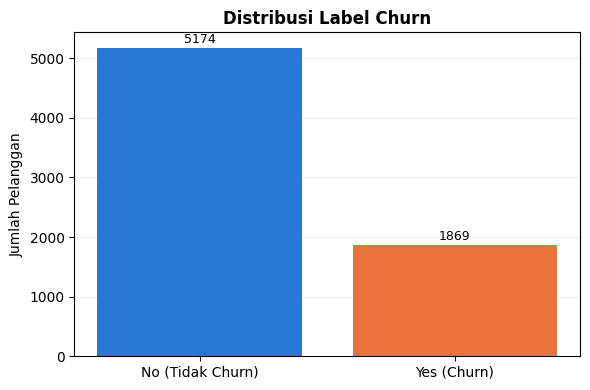

In [5]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

churn_counts = data['Churn'].value_counts()[['No', 'Yes']]

print('Distribusi label Churn:')
print(churn_counts.to_string())
print(f'\nKelas mayoritas: {churn_counts.idxmax()} '
      f'({churn_counts.max() / len(data) * 100:.1f}% dari seluruh data)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['No (Tidak Churn)', 'Yes (Churn)'], churn_counts.values, color=['#2a78d6', '#e8743b'])
ax.set_ylabel('Jumlah Pelanggan')
ax.set_title('Distribusi Label Churn', fontsize=12, fontweight='bold')
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 30, str(v), ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', color='#f0efec', lw=.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

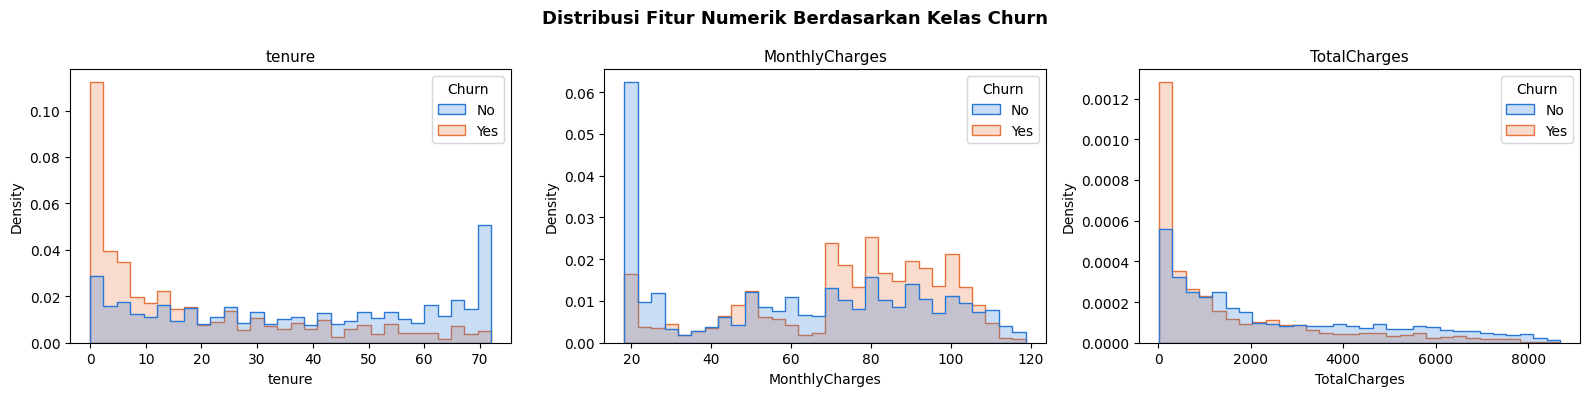

Median fitur numerik per kelas:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No       38.0          64.425       1683.60
Yes      10.0          79.650        703.55


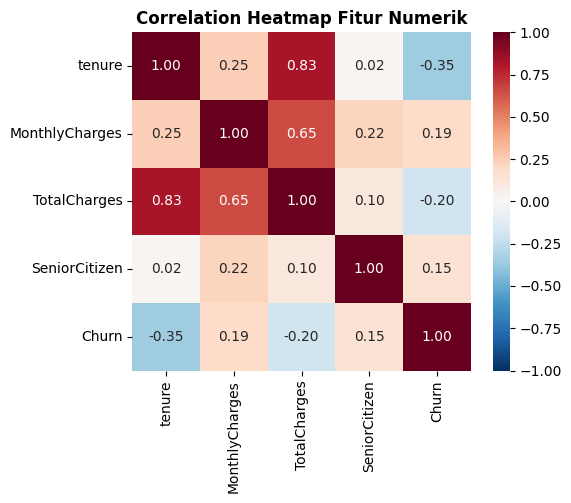

In [6]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.

# Fitur numerik dibandingkan antar kelas memakai histogram (density, supaya kelas kecil tetap terlihat).
fitur_numerik = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, fitur in zip(axes, fitur_numerik):
    sns.histplot(data=data, x=fitur, hue='Churn', hue_order=['No', 'Yes'], bins=30, stat='density',
                 common_norm=False, element='step', palette=['#2a78d6', '#e8743b'], ax=ax)
    ax.set_title(fitur, fontsize=11)
plt.suptitle('Distribusi Fitur Numerik Berdasarkan Kelas Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Median fitur numerik per kelas:')
print(data.groupby('Churn')[fitur_numerik].median())

# Correlation heatmap antar fitur numerik dan target (Churn diubah sementara ke 0/1 hanya untuk menghitung korelasi)
korelasi_df = data[fitur_numerik + ['SeniorCitizen']].copy()
korelasi_df['Churn'] = (data['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(6, 5))
sns.heatmap(korelasi_df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap Fitur Numerik', fontweight='bold')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Jumlah baris duplikat (tanpa customerID): 22


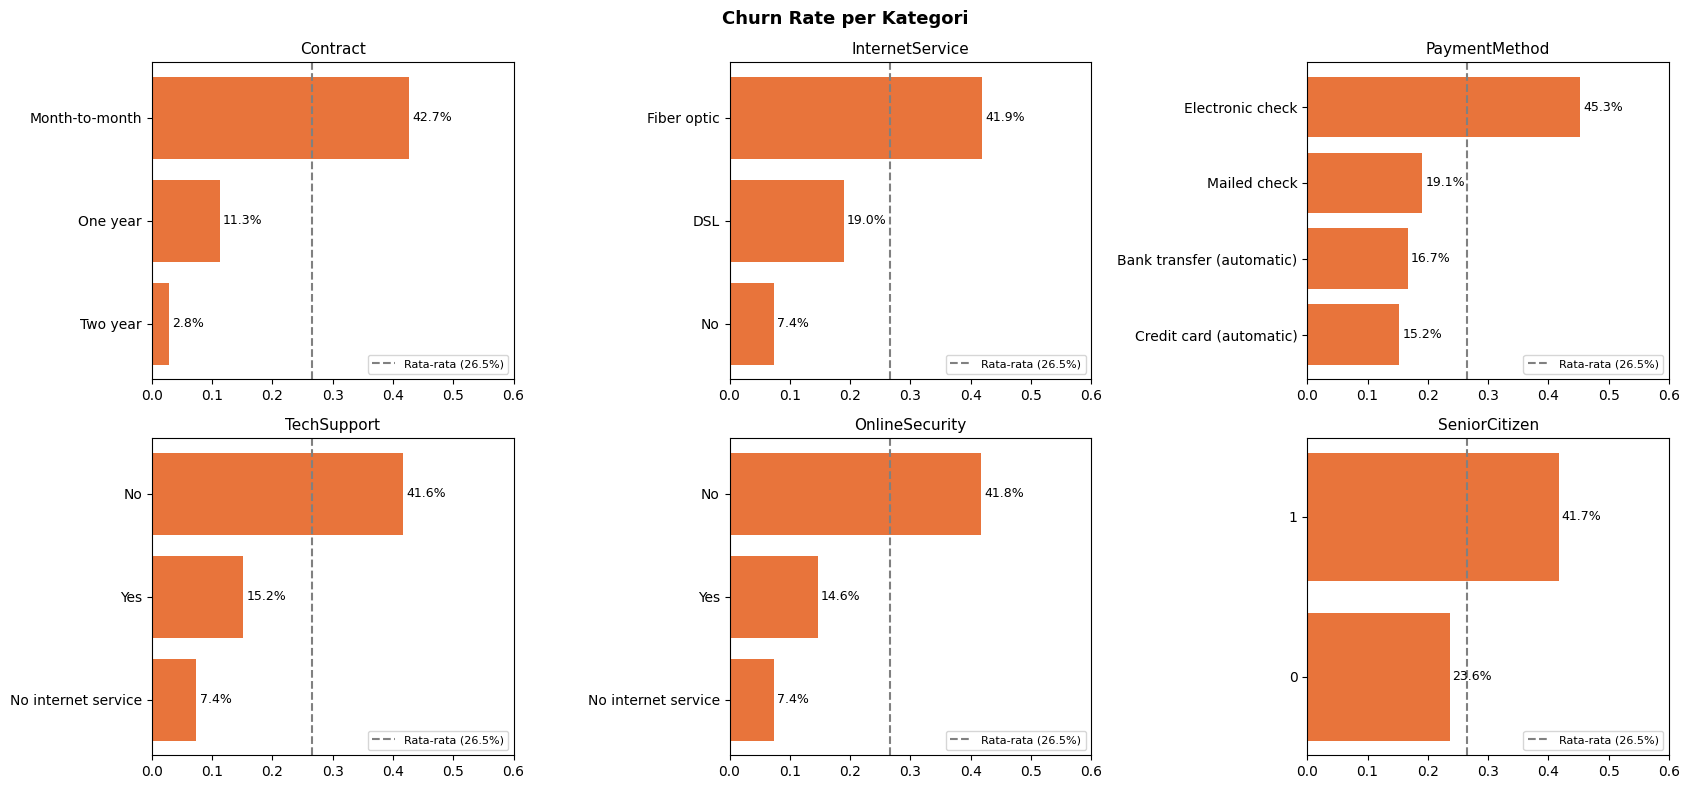

In [7]:
# EDA tambahan:
# 1) Cek data duplikat. customerID diabaikan karena ID pasti unik.
print('Jumlah baris duplikat (tanpa customerID):', data.drop(columns='customerID').duplicated().sum())
# Baris ini berasal dari customerID yang berbeda, jadi tetap dianggap pelanggan yang berbeda dan tidak dihapus.

# 2) Churn rate (persentase pelanggan yang churn) untuk setiap kategori pada beberapa fitur kategorikal.
churn_rate_total = (data['Churn'] == 'Yes').mean()
fitur_kategori = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity', 'SeniorCitizen']

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, fitur in zip(axes.flatten(), fitur_kategori):
    rate = data.groupby(fitur)['Churn'].apply(lambda s: (s == 'Yes').mean()).sort_values()
    ax.barh(rate.index.astype(str), rate.values, color='#e8743b')
    ax.axvline(churn_rate_total, ls='--', color='gray', label=f'Rata-rata ({churn_rate_total:.1%})')
    for i, v in enumerate(rate.values):
        ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9)
    ax.set_title(fitur, fontsize=11)
    ax.set_xlim(0, 0.6)
    ax.legend(fontsize=8, loc='lower right')
plt.suptitle('Churn Rate per Kategori', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Preprocessing

In [8]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

print('Kolom dengan missing value:')
print(data.isnull().sum()[data.isnull().sum() > 0].to_string())

# Lihat baris yang TotalCharges-nya kosong
print()
print(data.loc[data['TotalCharges'].isnull(), ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])

# Semua baris tersebut punya tenure = 0, artinya pelanggan baru yang belum pernah ditagih.
# Jadi nilai yang paling masuk akal adalah 0 (belum ada total tagihan).
# Strategi ini tidak memakai statistik dari data (seperti mean/median), sehingga tidak ada data leakage dari test set.
data['TotalCharges'] = data['TotalCharges'].fillna(0)

# customerID hanya identitas unik, tidak punya informasi untuk prediksi, jadi dihapus.
data = data.drop(columns=['customerID'])

print('\nTotal missing value setelah ditangani:', data.isnull().sum().sum())
print('Ukuran data:', data.shape)

Kolom dengan missing value:
TotalCharges    11



      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           NaN    No
753        0           20.25           NaN    No
936        0           80.85           NaN    No
1082       0           25.75           NaN    No
1340       0           56.05           NaN    No
3331       0           19.85           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
5218       0           19.70           NaN    No
6670       0           73.35           NaN    No
6754       0           61.90           NaN    No

Total missing value setelah ditangani: 0
Ukuran data: (7043, 20)


In [9]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).

# Target: Yes -> 1 (Churn), No -> 0 (Tidak Churn)
data['Churn'] = data['Churn'].map({'No': 0, 'Yes': 1})

kolom_kategorikal = data.select_dtypes(include='object').columns.tolist()
print('Fitur kategorikal:', kolom_kategorikal)

# One-Hot Encoding dipakai karena kategorinya nominal (tidak punya urutan).
# drop_first=True membuang satu kolom per fitur yang redundan (misalnya gender_Male sudah cukup mewakili gender).
# One-Hot Encoding tidak menghitung statistik dari data, jadi aman dilakukan sebelum split.
data_encoded = pd.get_dummies(data, columns=kolom_kategorikal, drop_first=True, dtype=int)
print('Ukuran data setelah encoding:', data_encoded.shape)
data_encoded.head()

Fitur kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Ukuran data setelah encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [10]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

from sklearn.model_selection import train_test_split

X = data_encoded.drop(columns=['Churn'])
y = data_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Proporsi kelas 1 (Churn) di train: %.3f | di test: %.3f' % (y_train.mean(), y_test.mean()))

Train: (5634, 30) | Test: (1409, 30)
Proporsi kelas 1 (Churn) di train: 0.265 | di test: 0.265


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [11]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.

from sklearn.preprocessing import StandardScaler

# Hanya fitur numerik kontinu yang discaling.
# Kolom hasil One-Hot Encoding dan SeniorCitizen sudah bernilai 0/1, jadi tidak perlu discaling.
kolom_numerik = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[kolom_numerik] = scaler.fit_transform(X_train[kolom_numerik])
X_test_scaled[kolom_numerik] = scaler.transform(X_test[kolom_numerik])

print('Sebelum scaling (train):')
print(X_train[kolom_numerik].describe().loc[['mean', 'std', 'min', 'max']].round(2))
print('\nSesudah scaling (train):')
print(X_train_scaled[kolom_numerik].describe().loc[['mean', 'std', 'min', 'max']].round(2))

Sebelum scaling (train):
      tenure  MonthlyCharges  TotalCharges
mean   32.49           64.93       2299.33
std    24.57           30.14       2279.20
min     0.00           18.40          0.00
max    72.00          118.75       8684.80

Sesudah scaling (train):
      tenure  MonthlyCharges  TotalCharges
mean   -0.00           -0.00          0.00
std     1.00            1.00          1.00
min    -1.32           -1.54         -1.01
max     1.61            1.79          2.80


# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [12]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).

from sklearn.neural_network import MLPClassifier

# max_iter dinaikkan dari default 200 menjadi 500 agar model punya cukup waktu untuk konvergen.
# Nilai yang sama dipakai di semua eksperimen agar perbandingan adil.
MAX_ITER = 500

model_base = MLPClassifier(hidden_layer_sizes=(10,), activation='relu', max_iter=MAX_ITER, random_state=42)
model_base.fit(X_train_scaled, y_train)
print('Iterasi sampai berhenti:', model_base.n_iter_, '| Loss akhir:', round(model_base.loss_, 4))

Iterasi sampai berhenti: 326 | Loss akhir: 0.3934


In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

from sklearn.metrics import accuracy_score

y_pred_base = model_base.predict(X_test_scaled)
print('Test Accuracy baseline:', round(accuracy_score(y_test, y_pred_base), 4))

Test Accuracy baseline: 0.797


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [14]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.

aktivasi_list = ['relu', 'tanh', 'logistic']
aktivasi_models = {}
for act in aktivasi_list:
    m = MLPClassifier(hidden_layer_sizes=(10,), activation=act, max_iter=MAX_ITER, random_state=42)
    m.fit(X_train_scaled, y_train)
    aktivasi_models[act] = m
    print(f'{act:<9} -> berhenti di iterasi ke-{m.n_iter_}, loss akhir {m.loss_:.4f}')

relu      -> berhenti di iterasi ke-326, loss akhir 0.3934


tanh      -> berhenti di iterasi ke-500, loss akhir 0.3879


logistic  -> berhenti di iterasi ke-153, loss akhir 0.4113


In [15]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.

hasil_aktivasi = pd.DataFrame({
    'Aktivasi': aktivasi_list,
    'Train Accuracy': [accuracy_score(y_train, m.predict(X_train_scaled)) for m in aktivasi_models.values()],
    'Test Accuracy': [accuracy_score(y_test, m.predict(X_test_scaled)) for m in aktivasi_models.values()],
    'Iterasi': [m.n_iter_ for m in aktivasi_models.values()],
})
hasil_aktivasi['Selisih (Train - Test)'] = hasil_aktivasi['Train Accuracy'] - hasil_aktivasi['Test Accuracy']
# Jika iterasi = max_iter, training berhenti karena batas iterasi, bukan karena loss sudah konvergen.
hasil_aktivasi['Konvergen'] = np.where(hasil_aktivasi['Iterasi'] < MAX_ITER, 'Ya', 'Tidak (max_iter tercapai)')

best_activation = hasil_aktivasi.loc[hasil_aktivasi['Test Accuracy'].idxmax(), 'Aktivasi']
print('Fungsi aktivasi dengan test accuracy tertinggi:', best_activation)
hasil_aktivasi.round(4)

Fungsi aktivasi dengan test accuracy tertinggi: logistic


,Aktivasi,Train Accuracy,Test Accuracy,Iterasi,Selisih (Train - Test),Konvergen
0,relu,0.8170,0.7970,326,0.0200,Ya
1,tanh,0.8225,0.7864,500,0.0361,Tidak (max_iter tercapai)
2,logistic,0.8062,0.8013,153,0.0049,Ya


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [16]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.

arsitektur_list = [(2,), (5,), (10,), (50,), (100,), (100, 50), (200, 100)]
arsitektur_models = {}
for h in arsitektur_list:
    m = MLPClassifier(hidden_layer_sizes=h, activation=best_activation, max_iter=MAX_ITER, random_state=42)
    m.fit(X_train_scaled, y_train)
    arsitektur_models[h] = m
print(f'Selesai melatih {len(arsitektur_models)} model dengan activation={best_activation}')

Selesai melatih 7 model dengan activation=logistic


In [17]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

train_acc, test_acc = [], []
for h, m in arsitektur_models.items():
    train_acc.append(accuracy_score(y_train, m.predict(X_train_scaled)))
    test_acc.append(accuracy_score(y_test, m.predict(X_test_scaled)))

hasil_arsitektur = pd.DataFrame({
    'hidden_layer_sizes': [str(h) for h in arsitektur_list],
    'Jumlah Parameter': [sum(w.size for w in m.coefs_) + sum(b.size for b in m.intercepts_) for m in arsitektur_models.values()],
    'Iterasi': [m.n_iter_ for m in arsitektur_models.values()],
    'Train Accuracy': train_acc,
    'Test Accuracy': test_acc,
    'Selisih (Train - Test)': np.array(train_acc) - np.array(test_acc),
})

best_arch = arsitektur_list[int(np.argmax(test_acc))]
print('Arsitektur dengan test accuracy tertinggi:', best_arch)
hasil_arsitektur.round(4)

Arsitektur dengan test accuracy tertinggi: (50,)


,hidden_layer_sizes,Jumlah Parameter,Iterasi,Train Accuracy,Test Accuracy,Selisih (Train - Test)
0,"(2,)",65,195,0.8033,0.7991,0.0042
1,"(5,)",161,211,0.8069,0.7977,0.0092
2,"(10,)",321,153,0.8062,0.8013,0.0049
3,"(50,)",1601,154,0.8072,0.8062,0.0010
4,"(100,)",3201,126,0.8051,0.8027,0.0024
5,"(100, 50)",8201,115,0.8064,0.8034,0.0029
6,"(200, 100)",26401,56,0.8037,0.7991,0.0045


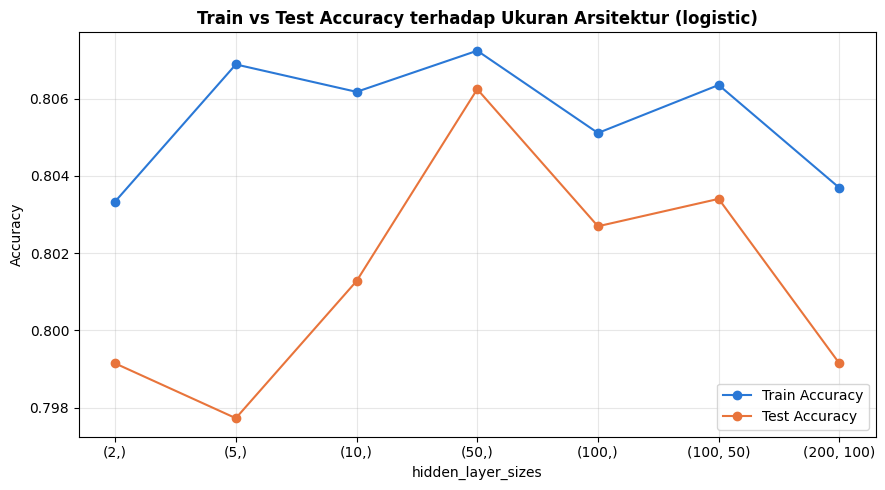

In [18]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

x_label = [str(h) for h in arsitektur_list]

plt.figure(figsize=(9, 5))
plt.plot(x_label, train_acc, marker='o', label='Train Accuracy', color='#2a78d6')
plt.plot(x_label, test_acc, marker='o', label='Test Accuracy', color='#e8743b')
plt.xlabel('hidden_layer_sizes')
plt.ylabel('Accuracy')
plt.title(f'Train vs Test Accuracy terhadap Ukuran Arsitektur ({best_activation})', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Tambahan: Pembanding dengan Aktivasi ReLU

Sebagai pembanding, variasi arsitektur yang sama juga dilatih dengan `activation='relu'` (aktivasi default di scikit-learn), untuk melihat apakah gejala overfitting terhadap ukuran arsitektur bergantung pada fungsi aktivasi yang dipakai.

,hidden_layer_sizes,Iterasi,Train Accuracy,Test Accuracy,Selisih (Train - Test)
0,"(2,)",110,0.8060,0.7977,0.0083
1,"(5,)",107,0.8080,0.7999,0.0081
2,"(10,)",326,0.8170,0.7970,0.0200
3,"(50,)",254,0.8346,0.7842,0.0503
4,"(100,)",500,0.8772,0.7715,0.1057
5,"(100, 50)",349,0.9526,0.7445,0.2081
6,"(200, 100)",229,0.9613,0.7544,0.2069


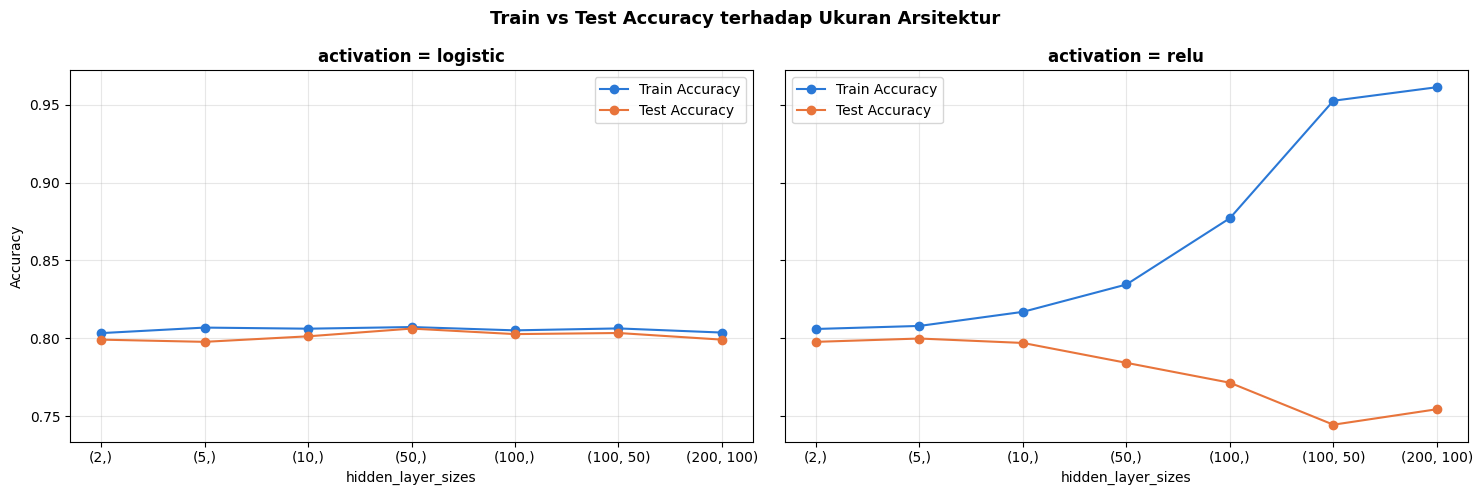

In [19]:
relu_models = {}
relu_train_acc, relu_test_acc = [], []
for h in arsitektur_list:
    m = MLPClassifier(hidden_layer_sizes=h, activation='relu', max_iter=MAX_ITER, random_state=42)
    m.fit(X_train_scaled, y_train)
    relu_models[h] = m
    relu_train_acc.append(accuracy_score(y_train, m.predict(X_train_scaled)))
    relu_test_acc.append(accuracy_score(y_test, m.predict(X_test_scaled)))

hasil_relu = pd.DataFrame({
    'hidden_layer_sizes': x_label,
    'Iterasi': [m.n_iter_ for m in relu_models.values()],
    'Train Accuracy': relu_train_acc,
    'Test Accuracy': relu_test_acc,
    'Selisih (Train - Test)': np.array(relu_train_acc) - np.array(relu_test_acc),
})
display(hasil_relu.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (nama, tr, te) in zip(axes, [(best_activation, train_acc, test_acc), ('relu', relu_train_acc, relu_test_acc)]):
    ax.plot(x_label, tr, marker='o', label='Train Accuracy', color='#2a78d6')
    ax.plot(x_label, te, marker='o', label='Test Accuracy', color='#e8743b')
    ax.set_title(f'activation = {nama}', fontweight='bold')
    ax.set_xlabel('hidden_layer_sizes')
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel('Accuracy')
plt.suptitle('Train vs Test Accuracy terhadap Ukuran Arsitektur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Tambahan: Pengaruh Jumlah Iterasi (`max_iter`) terhadap Overfitting

Secara default, `MLPClassifier` berhenti lebih awal jika training loss tidak turun lebih dari `tol` (1e-4) selama `n_iter_no_change` (10) epoch berturut-turut. Akibatnya, menaikkan `max_iter` belum tentu membuat model berlatih lebih lama. Agar pengaruh jumlah iterasi terlihat jelas, pada eksperimen ini `n_iter_no_change` dibuat sangat besar sehingga model berlatih tepat sebanyak `max_iter` epoch. Arsitektur yang dipakai adalah `(100, 50)` dengan fungsi aktivasi terbaik dari 3.2.

,max_iter,Training Loss,Train Accuracy,Test Accuracy,Selisih (Train - Test)
0,10,0.4217,0.8040,0.7949,0.0092
1,50,0.4147,0.8021,0.7970,0.0051
2,100,0.4117,0.8064,0.8027,0.0037
3,200,0.4066,0.8095,0.8034,0.0061
4,500,0.3936,0.8159,0.7906,0.0253
5,1000,0.3632,0.8333,0.7821,0.0512
6,2000,0.2567,0.8839,0.7410,0.1430


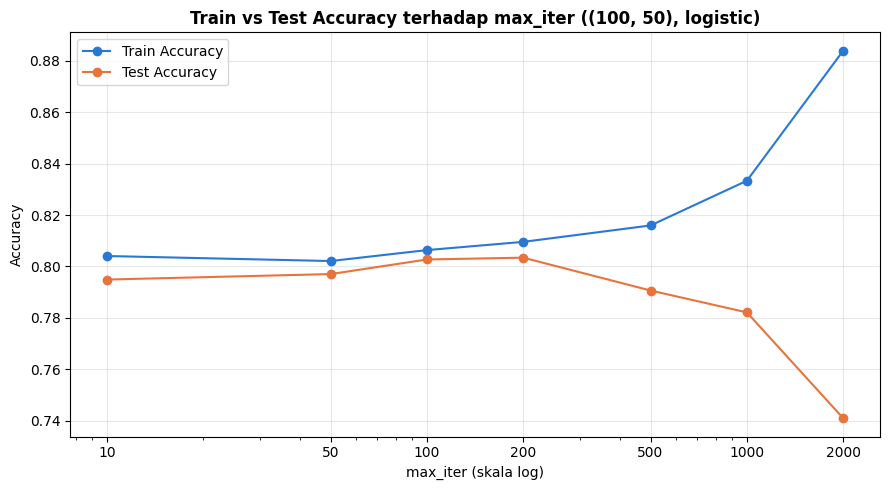

In [20]:
iter_list = [10, 50, 100, 200, 500, 1000, 2000]
iter_train_acc, iter_test_acc, iter_loss = [], [], []
for it in iter_list:
    m = MLPClassifier(hidden_layer_sizes=(100, 50), activation=best_activation, max_iter=it,
                      n_iter_no_change=10_000, random_state=42)  # n_iter_no_change besar = tidak berhenti lebih awal
    m.fit(X_train_scaled, y_train)
    iter_train_acc.append(accuracy_score(y_train, m.predict(X_train_scaled)))
    iter_test_acc.append(accuracy_score(y_test, m.predict(X_test_scaled)))
    iter_loss.append(m.loss_)

hasil_iter = pd.DataFrame({
    'max_iter': iter_list,
    'Training Loss': iter_loss,
    'Train Accuracy': iter_train_acc,
    'Test Accuracy': iter_test_acc,
    'Selisih (Train - Test)': np.array(iter_train_acc) - np.array(iter_test_acc),
})
display(hasil_iter.round(4))

plt.figure(figsize=(9, 5))
plt.plot(iter_list, iter_train_acc, marker='o', label='Train Accuracy', color='#2a78d6')
plt.plot(iter_list, iter_test_acc, marker='o', label='Test Accuracy', color='#e8743b')
plt.xscale('log')
plt.xticks(iter_list, [str(i) for i in iter_list])
plt.xlabel('max_iter (skala log)')
plt.ylabel('Accuracy')
plt.title(f'Train vs Test Accuracy terhadap max_iter ((100, 50), {best_activation})', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [21]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

from sklearn.metrics import precision_score, recall_score, f1_score

# Precision, Recall, dan F1 dihitung untuk kelas 1 (Churn), yaitu kelas yang ingin dideteksi.
def hitung_metrik(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
    }

kandidat = {
    'Baseline: relu (10,)': model_base,
    f'Terbaik 3.2: {best_activation} (10,)': aktivasi_models[best_activation],
    f'Terbaik 3.3: {best_activation} {best_arch}': arsitektur_models[best_arch],
}
tabel_metrik = pd.DataFrame({nama: hitung_metrik(y_test, m.predict(X_test_scaled)) for nama, m in kandidat.items()}).T

# Model terbaik = test accuracy tertinggi di antara model terbaik eksperimen 3.2 dan 3.3
best_name = tabel_metrik.iloc[1:]['Accuracy'].idxmax()
best_model = kandidat[best_name]
print('Model dengan performa terbaik:', best_name)
tabel_metrik.round(4)

Model dengan performa terbaik: Terbaik 3.3: logistic (50,)


,Accuracy,Precision,Recall,F1-Score
"Baseline: relu (10,)",0.7970,0.6350,0.5535,0.5914
"Terbaik 3.2: logistic (10,)",0.8013,0.6516,0.5401,0.5906
"Terbaik 3.3: logistic (50,)",0.8062,0.6624,0.5508,0.6015


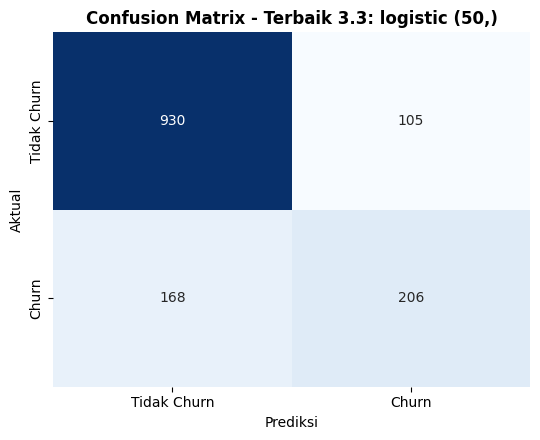

In [22]:
# Tampilkan Confusion Matrix untuk model dengan performa terbaik dalam bentuk heatmap.

from sklearn.metrics import confusion_matrix

y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Tidak Churn', 'Churn'], yticklabels=['Tidak Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_name}', fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

Iterasi: 154 dari max_iter=500 | Loss akhir: 0.4106
Training berhenti sebelum max_iter karena loss sudah tidak turun lebih dari tol selama 10 epoch (konvergen).


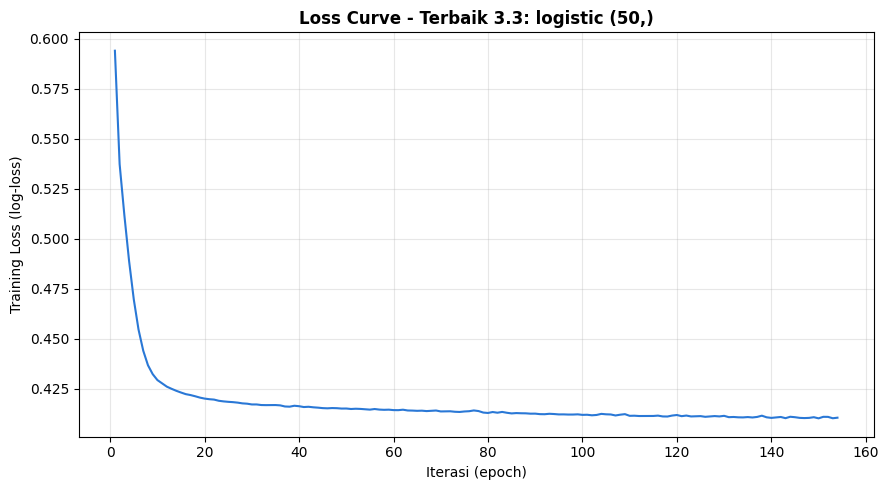

In [23]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.

print(f'Iterasi: {best_model.n_iter_} dari max_iter={MAX_ITER} | Loss akhir: {best_model.loss_:.4f}')
if best_model.n_iter_ < MAX_ITER:
    print('Training berhenti sebelum max_iter karena loss sudah tidak turun lebih dari tol selama 10 epoch (konvergen).')
else:
    print('Training berhenti karena max_iter tercapai (belum tentu konvergen).')

plt.figure(figsize=(9, 5))
plt.plot(range(1, best_model.n_iter_ + 1), best_model.loss_curve_, color='#2a78d6')
plt.xlabel('Iterasi (epoch)')
plt.ylabel('Training Loss (log-loss)')
plt.title(f'Loss Curve - {best_name}', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa ANN dengan fungsi aktivasi ReLU, Tanh, dan Logistic. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (ukuran arsitektur). Pada ukuran arsitektur berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Berdasarkan loss curve yang dihasilkan, apakah model sudah cukup konvergen? Apa yang akan kalian lakukan jika loss curve masih menurun tajam saat max_iter tercapai?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

### Jawaban Analisis

**1. Perbandingan Fungsi Aktivasi (`(10,)`, `max_iter=500`)**

| Aktivasi | Train Acc | Test Acc | Iterasi |
|---|---|---|---|
| relu | 0.8170 | 0.7970 | 326 |
| tanh | 0.8225 | 0.7864 | 500 (belum konvergen) |
| logistic | 0.8062 | **0.8013** | 153 |

- Hasilnya tidak berbeda signifikan. Logistic terbaik, tetapi selisihnya dengan ReLU hanya sekitar 6 dari 1409 pelanggan.
- Pola churn cukup sederhana (dari EDA: kontrak Month-to-month, Fiber optic, dan tenure kecil), sehingga jaringan kecil dengan aktivasi apa pun bisa menangkapnya. Arsitektur `(2,)` saja sudah mencapai 0.7991.
- Tanh belajar paling agresif (train tertinggi, test terendah, belum konvergen), yang merupakan tanda awal overfitting. Gradien logistic kecil sehingga training berhenti lebih cepat, dan generalisasinya paling stabil.

**2. Pengaruh Ukuran Arsitektur**

- **Logistic:** tidak ada overfitting. Train tetap di 0.803–0.807 dan test di 0.798–0.806 untuk semua arsitektur. Penyebabnya, loss cepat mendatar sehingga training berhenti lebih awal (`(200, 100)` hanya 56 iterasi). Arsitektur terbaik adalah `(50,)` dengan test 0.8062.
- **ReLU (pembanding):** overfitting mulai terlihat pada `(50,)` dan makin parah pada `(100, 50)`, dengan train 0.95 vs test 0.74. Di grafik, garis train naik tajam sementara garis test turun, sehingga jaraknya terus melebar.
- **`max_iter`:** jika `(100, 50)` logistic dipaksa berlatih sampai 2000 iterasi, model juga overfitting (train 0.88 vs test 0.74). Jadi overfitting dipengaruhi oleh ukuran arsitektur dan lama training.

**3. Loss Curve**

- Loss model terbaik (logistic, `(50,)`) turun tajam di ~10 epoch pertama, lalu mendatar. Training berhenti di iterasi 154 (< `max_iter=500`), artinya model sudah konvergen.
- Jika loss masih turun tajam saat `max_iter` tercapai: naikkan `max_iter` atau `learning_rate_init`, dan gunakan `early_stopping=True` agar training berhenti saat skor validasi tidak membaik lagi.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba solver lain seperti 'sgd', menambahkan regularisasi alpha, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

### Kesimpulan

- Model terbaik adalah logistic dengan `hidden_layer_sizes=(50,)`: accuracy 0.8062, F1 0.6015. Perbedaan antar fungsi aktivasi tidak signifikan.
- Arsitektur besar dan training yang terlalu lama menyebabkan overfitting. Pada data ini, jaringan kecil sudah cukup.
- Recall kelas Churn masih rendah (55%), jadi accuracy saja kurang tepat untuk menilai model pada data imbalanced.

### Saran

1. Gunakan `GridSearchCV` + cross-validation untuk memilih activation, arsitektur, dan `alpha`.
2. Tambahkan regularisasi (`alpha`, `early_stopping=True`), terutama untuk ReLU dengan arsitektur besar.
3. Tangani imbalance (misalnya SMOTE pada train set atau menurunkan threshold) agar recall kelas Churn naik.
4. Bandingkan dengan model lain seperti Logistic Regression atau Random Forest.